Smart City surveillance system (IoT)

In [1]:
import os
import cv2 as cv
import numpy as np
from imutils import paths
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from keras.applications import ResNet50
from keras.layers import Input, Flatten, Dropout, Dense
from keras.layers import AveragePooling2D
from keras.optimizers import SGD
from keras.models import Model
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

from IPython.display import clear_output
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.preprocessing import LabelBinarizer

In [4]:
datapath = './data'
outputModel = ('./model/theftSurvModel')
outputLB = ('./model/theftSurvLB')
epoch = 25

theft_types =os.listdir(datapath)
n=len(theft_types)
print("Number of categories in dataset : ",n)

elements = [element for element in os.listdir(datapath)]

# Print all elements in the list elements
for element in elements:
    print(element)

Number of categories in dataset :  4
NormalVideos
Robbery
Shoplifting
Stealing


In [5]:
#Storing the number of files for each class in the 'datapath' dictionary
theft={}
train=test=0
for clss in theft_types:
    num=len(os.listdir(os.path.join(datapath,clss)))
    train+=num
    
    theft[clss] = num
    

In [6]:
#09/10/2023 test using crime dataset
theft_labels = set(['NomarlVideos', 'Burglary', 'Shoplifting', 'Robbery', 'Stealing'])

print ('Images are being loaded.....')

pathToimages = list(paths.list_images(datapath))
data = []
labels = []

for images in pathToimages:
    #label = images.split(os.path.sep)[-2]
    label = os.path.basename(os.path.dirname(images))
    if label not in theft_labels:
        continue
    image = cv.imread(images)
    image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
    image = cv.resize(image, (64,64))
    data.append(image)
    labels.append(label)

Images are being loaded.....


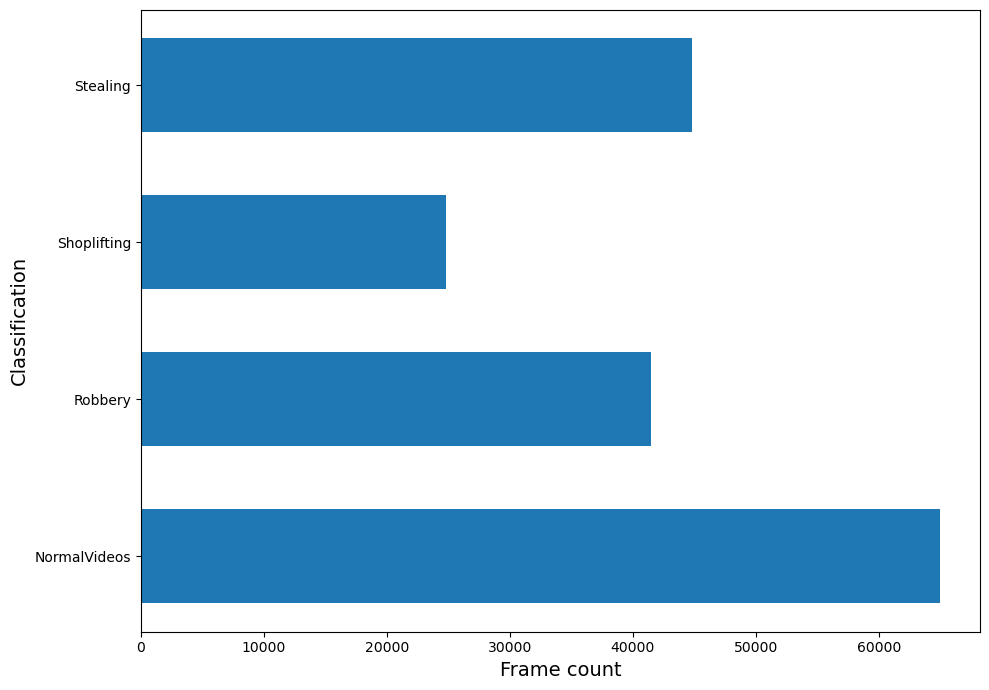

In [7]:
plt.figure(figsize=(10, 7))
plt.barh(list(theft.keys()), list(theft.values()), height=0.6, align="center")
plt.yticks(rotation=0)

plt.xlabel("Frame count", fontsize=14)
plt.ylabel("Classification", fontsize=14)
plt.tight_layout()
plt.show()

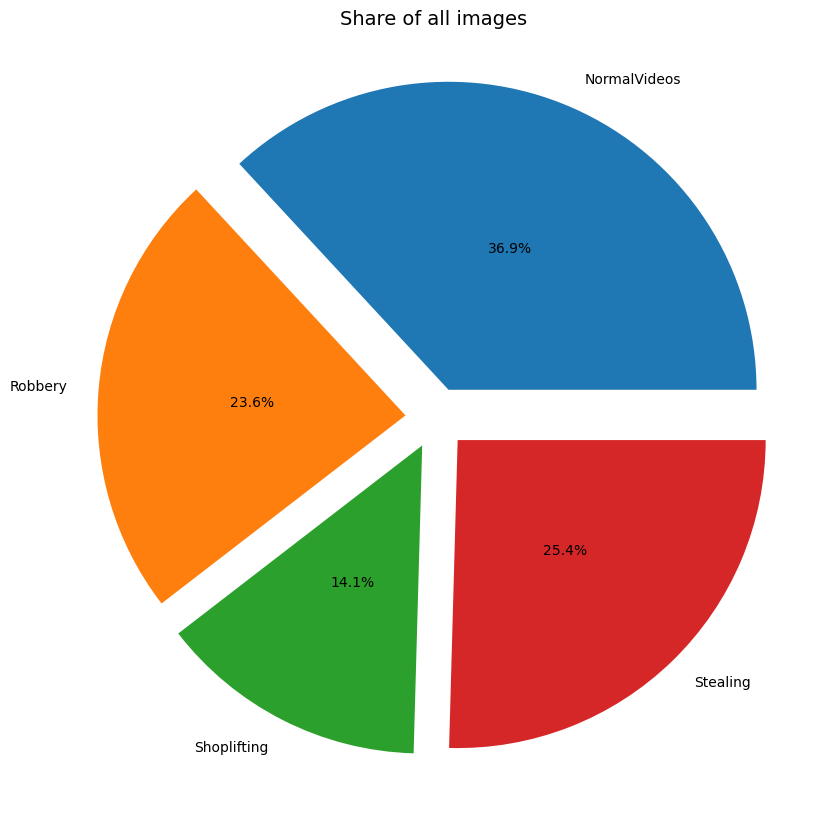

In [16]:
plt.figure(figsize=(15,10))
plt.pie(x=np.array(list(theft.values())), autopct="%.1f%%", explode=[0.1]*n,labels=list(theft.keys()), pctdistance=0.5)
plt.title("Share of all images ", fontsize=14);

In [12]:
data = np.array(data)
labels = np.array(labels)

#hot encode theft laabes as 0,1,2,3,4
""" lb = LabelBinarizer()
labels = lb.fit_transform(labels, label_mode = 'categorical') """

""" lb = LabelBinarizer(label_mode='categorical')
labels = lb.fit_transform(labels) """

lb = LabelBinarizer()
lb.label_mode = 'categorical'
labels = lb.fit_transform(labels)


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X, y = data, labels
(X_train, x_test, Y_train, y_test) = train_test_split(data, labels, test_size = 0.20, stratify = labels, random_state = 42)

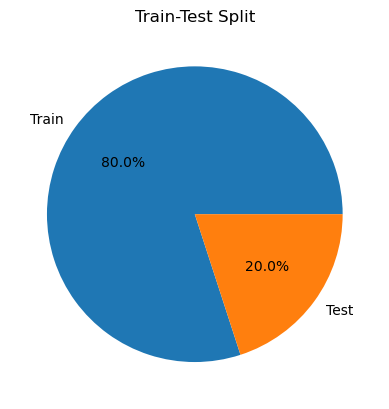

In [17]:
# Create a pie chart of the train and test set sizes
plt.pie([X_train.shape[0], x_test.shape[0]], labels=["Train", "Test"], autopct="%1.1f%%")
plt.title("Train-Test Split")
plt.show()

In [18]:
from keras.preprocessing.image import ImageDataGenerator

In [19]:
trainingArgumentation = ImageDataGenerator(
    rotation_range = 30,
    zoom_range = 15,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.15,
    horizontal_flip = True,
    fill_mode = 'nearest'
)

validationArgumentation = ImageDataGenerator()
mean = np.array([123.68, 116.779, 103.939], dtype = 'float32')

trainingArgumentation.mean = mean

validationArgumentation.mean = mean

In [20]:
#transfer learning from resnet model
baseModel = ResNet50(
    weights = 'imagenet',
    include_top = False,
    input_tensor = Input(shape = (64,64,3))
)

headModel = baseModel.output
headModel = AveragePooling2D(pool_size = (2,2))(headModel)

headModel = Flatten(name = 'flatten')(headModel)

headModel = Dense(512, activation = 'relu')(headModel)

headModel = Dropout(0.5)(headModel)

headModel = Dense(len(lb.classes_), activation = 'softmax')(headModel)

model = Model(inputs = baseModel.input, outputs = headModel)

for basemodellayers in baseModel.layers:
    basemodellayers.trainable = False



In [21]:
#since we imported from keras.optimizers import SGD
opt = SGD(learning_rate = 0.0001, momentum = 0.9)

In [22]:
model.compile(loss = 'categorical_crossentropy', optimizer = opt, metrics = ['accuracy'])

In [23]:
History = model.fit(
    trainingArgumentation.flow(X_train, Y_train, batch_size = 64),
    steps_per_epoch = len(X_train) // 64,
    validation_data = validationArgumentation.flow(x_test, y_test),
    validation_steps = len(x_test) // 64,
    epochs = epoch
)

Epoch 1/25
1389/1389 [==============================] - 1461s 1s/step - loss: 1.1161 - accuracy: 0.5381 - val_loss: 0.9668 - val_accuracy: 0.5191
Epoch 2/25
1389/1389 [==============================] - 1252s 901ms/step - loss: 0.8447 - accuracy: 0.6155 - val_loss: 0.9215 - val_accuracy: 0.5371
Epoch 3/25
1389/1389 [==============================] - 1118s 805ms/step - loss: 0.7967 - accuracy: 0.6428 - val_loss: 0.9299 - val_accuracy: 0.5479
Epoch 4/25
1389/1389 [==============================] - 1162s 836ms/step - loss: 0.7673 - accuracy: 0.6561 - val_loss: 0.8788 - val_accuracy: 0.5840
Epoch 5/25
1389/1389 [==============================] - 1149s 827ms/step - loss: 0.7420 - accuracy: 0.6696 - val_loss: 0.8723 - val_accuracy: 0.5877
Epoch 6/25
1389/1389 [==============================] - 1061s 764ms/step - loss: 0.7280 - accuracy: 0.6772 - val_loss: 0.8591 - val_accuracy: 0.5933
Epoch 7/25
1389/1389 [==============================] - 1040s 749ms/step - loss: 0.7099 - accuracy: 0.6869 - 

In [24]:
print ("[INFO] evaluating network...")
y_score = model.predict(x_test, batch_size=64)

[INFO] evaluating network...
348/348 [==============================] - 226s 639ms/step


In [25]:
# evaluate the network
print ("[INFO] evaluating network...")
y_score = model.predict(x_test, batch_size=64)
print(classification_report(y_test.argmax(axis=1),
	y_score.argmax(axis=1), target_names=lb.classes_))

[INFO] evaluating network...
348/348 [==============================] - 199s 573ms/step
              precision    recall  f1-score   support

     Robbery       0.54      0.70      0.61      8299
 Shoplifting       0.53      0.53      0.53      4967
    Stealing       0.86      0.64      0.73      8960

    accuracy                           0.64     22226
   macro avg       0.65      0.62      0.62     22226
weighted avg       0.67      0.64      0.64     22226



In [26]:
import pickle

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


<Figure size 640x480 with 0 Axes>

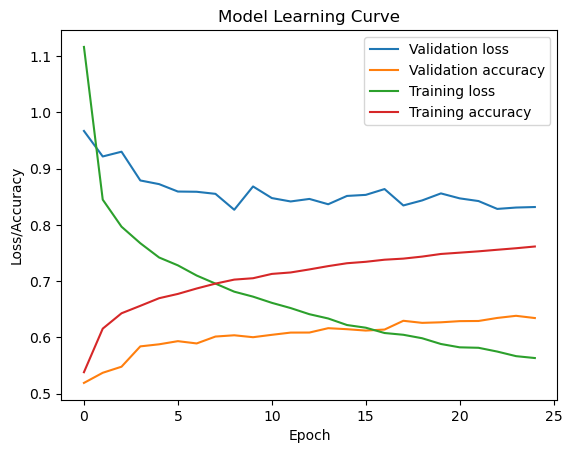

In [27]:
#Plot Learning Curve
plt.clf() 
plt.figure(4)
plt.plot(History.history["val_loss"], label="val_loss")
plt.plot(History.history["val_accuracy"], label="val_acc")
plt.plot(History.history["loss"], label="train_loss")
plt.plot(History.history["accuracy"], label="train_acc")
plt.title('Model Learning Curve')
plt.ylabel('Loss/Accuracy')
plt.xlabel('Epoch')
plt.legend(['Validation loss', 'Validation accuracy', 'Training loss', 'Training accuracy'], loc='upper right')
plt.savefig('./visualisation/Learning-curve.eps', format='eps', dpi=1000)
plt.savefig('./visualisation/Learning-curve.png', format='png', bbox_inches='tight')

In [36]:
from sklearn.metrics import confusion_matrix
def plot_confusion_matrix1(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if not title:
        if normalize:
            title = 'Normalized confusion matrix'
        else:
            title = 'Confusion matrix, without normalization'

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Only use the labels that appear in the data
    #classes = classes[unique_labels(y_true, y_pred)]
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the respective list entries
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax


np.set_printoptions(precision=2)

y_test = y_test.argmax(axis=1)
y_pred = y_score.argmax(axis=1)
lb = ["NormalVideos", "Robbery ", "Stealing", "Shoplifting", ]
# Plot normalized confusion matrix
plot_confusion_matrix1(y_test, y_pred, classes=lb, normalize=True,
                      title='Normalized confusion matrix')

#plt.show()
#plt.clf()
#plt.figure(6)
#plt.savefig('CM.eps', format='eps', dpi=1000)
plt.savefig('./visualisation/CM.png', format='png', dpi=1000)
plt.savefig('./plots/CM.tiff', format='tiff', dpi=1000)


AxisError: axis 1 is out of bounds for array of dimension 1

In [37]:
model.save(outputModel)
lbinarizer = open('./model/theftSurvLB.pickle','wb')
lbinarizer.write(pickle.dumps(lb))
lbinarizer.close()

INFO:tensorflow:Assets written to: ./model/theftSurvModel\assets


INFO:tensorflow:Assets written to: ./model/theftSurvModel\assets
